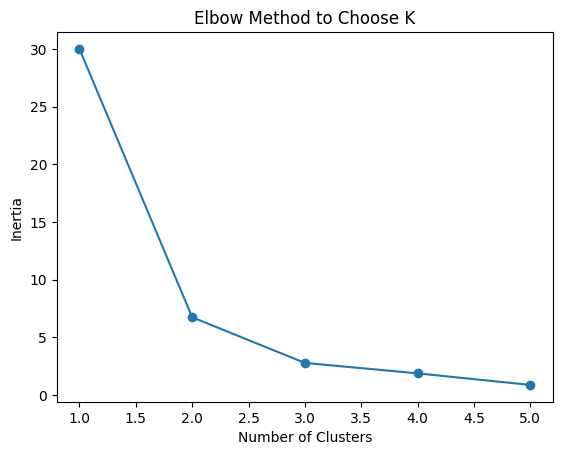

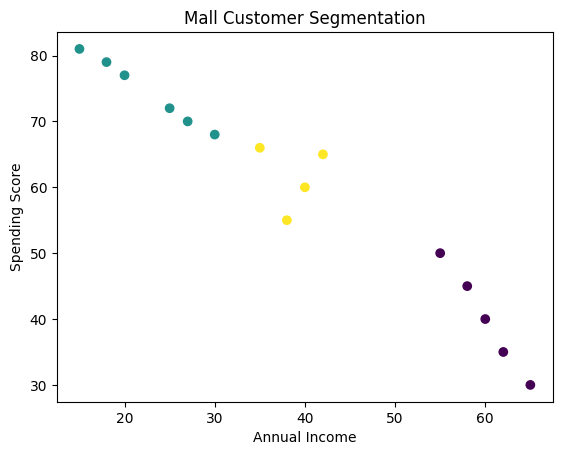

Customer Segments:

    Age  Income  SpendingScore  Segment
0    22      15             81        1
1    25      18             79        1
2    47      60             40        0
3    52      62             35        0
4    46      58             45        0
5    23      20             77        1
6    35      40             60        2
7    33      42             65        2
8    27      25             72        1
9    29      27             70        1
10   41      55             50        0
11   50      65             30        0
12   36      38             55        2
13   28      30             68        1
14   30      35             66        2


In [1]:
# Customer Segmentation using K-Means

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Creating a small mall customer dataset manually
customers = {
    "Age": [22, 25, 47, 52, 46, 23, 35, 33, 27, 29, 41, 50, 36, 28, 30],
    "Income": [15, 18, 60, 62, 58, 20, 40, 42, 25, 27, 55, 65, 38, 30, 35],
    "SpendingScore": [81, 79, 40, 35, 45, 77, 60, 65, 72, 70, 50, 30, 55, 68, 66]
}

df = pd.DataFrame(customers)

# Selecting features
X = df[["Income", "SpendingScore"]]

# Scaling data for better clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Finding best number of clusters using Elbow Method
inertia_values = []
for i in range(1, 6):
    model = KMeans(n_clusters=i, random_state=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

# Plot elbow graph
plt.plot(range(1,6), inertia_values, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method to Choose K")
plt.show()

# Applying K-Means with chosen clusters
kmeans = KMeans(n_clusters=3, random_state=10)
df["Segment"] = kmeans.fit_predict(X_scaled)

# Plot customer segments
plt.scatter(df["Income"], df["SpendingScore"], c=df["Segment"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Mall Customer Segmentation")
plt.show()

# Print segmented dataset
print("Customer Segments:\n")
print(df)